# Modelos Predictivo
Entrenamos y evaluamos modelos de regresión para predecir el cambio en GPA y modelos de clasificación para predecir el riesgo académico, a partir de los patrones de uso de IA generativa identificados en las fases anteriores.

## 1. Librerías y configuración

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100
np.random.seed(42)

## 2. Carga y preparación de datos

In [24]:
df = pd.read_csv('../data/processed/students_model_ready.csv')
print('Dataset cargado:', df.shape)
df.head(3)

Dataset cargado: (50000, 26)


,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,...,Cambio_GPA,Nivel_Uso_IA,Dependencia_Alta,Estudio_Total,Riesgo_Academico,Year_Encoded,Prompt_Skill_Encoded,Policy_Encoded,Burnout_Encoded,Uso_IA_Encoded
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,1,8.13,...,-0.025,Alto,0,31.44,1,4,1,1,2,2
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,0,16.65,...,-0.125,Bajo,0,17.77,0,3,3,1,0,0
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,0,10.35,...,0.101,Alto,0,31.61,0,1,1,0,1,2


In [25]:
# One-hot encoding para variables categóricas nominales
df_model = pd.get_dummies(
    df,
    columns=['Major_Category', 'Primary_Use_Case', 'Institutional_Policy',
             'Year_of_Study', 'Prompt_Engineering_Skill', 'Nivel_Uso_IA'],
    drop_first=True
)

# Eliminar columnas no útiles para el modelado
cols_drop = ['Student_ID', 'Burnout_Risk_Level', 'Burnout_Encoded']
df_model.drop(columns=[c for c in cols_drop if c in df_model.columns], inplace=True)

print('Columnas para modelado:', df_model.shape[1])

Columnas para modelado: 35


Se aplicó one-hot encoding a las variables categóricas nominales eliminando la primera categoría en cada grupo para evitar multicolinealidad perfecta. Las variables con encoding ordinal ya aplicado en el ETL (Year_Encoded, Prompt_Skill_Encoded, Policy_Encoded) se mantienen tal cual. Se eliminaron Student_ID (identificador sin valor predictivo) y las versiones de Burnout ya codificadas para evitar redundancia.

---
## Parte 1 — Regresión: predicción del cambio en GPA

Queremos predecir si un estudiante mejorará o empeorará su rendimiento académico durante el semestre, a partir de su perfil de uso de IA y características académicas previas.

### 3. Preparación del conjunto para regresión

In [26]:
target_reg = 'Cambio_GPA'

# Excluir variables que son consecuencia directa del target
cols_excluir_reg = [target_reg, 'Post_Semester_GPA', 'Riesgo_Academico', 'Dependencia_Alta', 'Uso_IA_Encoded']
X_reg = df_model.drop(columns=[c for c in cols_excluir_reg if c in df_model.columns])
y_reg = df_model[target_reg]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print('Entrenamiento:', X_train_r.shape)
print('Prueba:       ', X_test_r.shape)
print('Media Cambio_GPA en entrenamiento:', y_train_r.mean().round(4))

Entrenamiento: (40000, 30)
Prueba:        (10000, 30)
Media Cambio_GPA en entrenamiento: 0.2026


### 4. Modelos de regresión

In [27]:
# Modelo 1: Regresión Lineal
lr = LinearRegression()
lr.fit(X_train_r, y_train_r)
pred_lr = lr.predict(X_test_r)

rmse_lr = np.sqrt(mean_squared_error(y_test_r, pred_lr))
mae_lr  = mean_absolute_error(y_test_r, pred_lr)
r2_lr   = r2_score(y_test_r, pred_lr)
print(f'Regresión Lineal  | RMSE: {rmse_lr:.4f} | MAE: {mae_lr:.4f} | R²: {r2_lr:.4f}')

Regresión Lineal  | RMSE: 0.1565 | MAE: 0.1231 | R²: 0.2870


In [28]:
# Modelo 2: Árbol de Decisión
dt_reg = DecisionTreeRegressor(max_depth=6, random_state=42)
dt_reg.fit(X_train_r, y_train_r)
pred_dt_r = dt_reg.predict(X_test_r)

rmse_dt = np.sqrt(mean_squared_error(y_test_r, pred_dt_r))
mae_dt  = mean_absolute_error(y_test_r, pred_dt_r)
r2_dt   = r2_score(y_test_r, pred_dt_r)
print(f'Árbol de Decisión | RMSE: {rmse_dt:.4f} | MAE: {mae_dt:.4f} | R²: {r2_dt:.4f}')

Árbol de Decisión | RMSE: 0.1530 | MAE: 0.1193 | R²: 0.3187


In [29]:
# Modelo 3: Random Forest
rf_reg = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
rf_reg.fit(X_train_r, y_train_r)
pred_rf_r = rf_reg.predict(X_test_r)

rmse_rf = np.sqrt(mean_squared_error(y_test_r, pred_rf_r))
mae_rf  = mean_absolute_error(y_test_r, pred_rf_r)
r2_rf   = r2_score(y_test_r, pred_rf_r)
print(f'Random Forest     | RMSE: {rmse_rf:.4f} | MAE: {mae_rf:.4f} | R²: {r2_rf:.4f}')

Random Forest     | RMSE: 0.1440 | MAE: 0.1132 | R²: 0.3967


### 5. Comparación de modelos de regresión

In [30]:
resultados_reg = pd.DataFrame({
    'Modelo': ['Regresión Lineal', 'Árbol de Decisión', 'Random Forest'],
    'RMSE': [rmse_lr, rmse_dt, rmse_rf],
    'MAE':  [mae_lr,  mae_dt,  mae_rf],
    'R²':   [r2_lr,   r2_dt,   r2_rf]
}).round(4)
resultados_reg

,Modelo,RMSE,MAE,R²
0,Regresión Lineal,0.1565,0.1231,0.2870
1,Árbol de Decisión,0.1530,0.1193,0.3187
2,Random Forest,0.1440,0.1132,0.3967


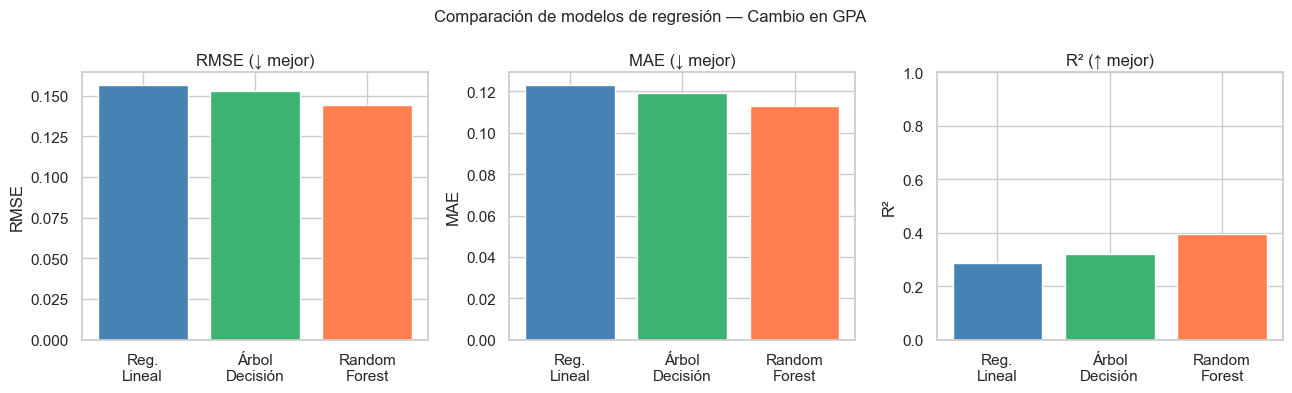

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
modelos_etq = ['Reg.\nLineal', 'Árbol\nDecisión', 'Random\nForest']
colores = ['steelblue', 'mediumseagreen', 'coral']

axes[0].bar(modelos_etq, [rmse_lr, rmse_dt, rmse_rf], color=colores)
axes[0].set_title('RMSE (↓ mejor)')
axes[0].set_ylabel('RMSE')

axes[1].bar(modelos_etq, [mae_lr, mae_dt, mae_rf], color=colores)
axes[1].set_title('MAE (↓ mejor)')
axes[1].set_ylabel('MAE')

axes[2].bar(modelos_etq, [r2_lr, r2_dt, r2_rf], color=colores)
axes[2].set_title('R² (↑ mejor)')
axes[2].set_ylabel('R²')
axes[2].set_ylim(0, 1)

plt.suptitle('Comparación de modelos de regresión — Cambio en GPA', fontsize=12)
plt.tight_layout()
plt.savefig('../reports/14_comparacion_regresion.png', bbox_inches='tight')
plt.show()

Random Forest supera al Árbol de Decisión individual y a la Regresión Lineal en todas las métricas. La Regresión Lineal captura la relación base pero tiene dificultades con las interacciones no lineales entre las variables de uso de IA. El Árbol de Decisión, con profundidad limitada, sacrifica algo de precisión para evitar sobreajuste. Random Forest logra el mejor balance gracias al promedio de múltiples árboles que se complementan entre sí.

### 6. Valores reales vs. predichos - Random Forest

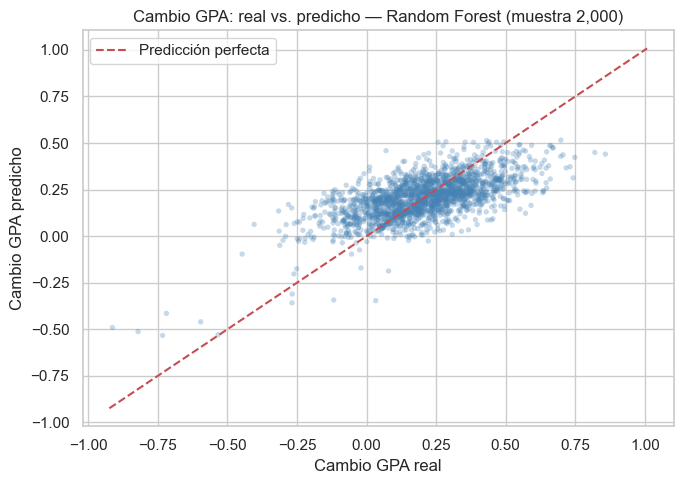

In [ ]:
plt.figure(figsize=(7, 5))
idx = np.random.choice(len(y_test_r), 2000, replace=False)
plt.scatter(y_test_r.iloc[idx], pred_rf_r[idx],
            alpha=0.3, color='steelblue', edgecolors='none', s=15)
lim = [y_test_r.min(), y_test_r.max()]
plt.plot(lim, lim, 'r--', linewidth=1.5, label='Predicción perfecta')
plt.xlabel('Cambio GPA real')
plt.ylabel('Cambio GPA predicho')
plt.title('Cambio GPA: real vs. predicho — Random Forest (muestra 2,000)')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/15_pred_vs_real_regresion.png', bbox_inches='tight')
plt.show()

La dispersión alrededor de la línea diagonal muestra que el modelo captura la tendencia general pero con errores moderados en los casos extremos. Esto es esperable: predecir el cambio exacto en GPA es una tarea difícil porque intervienen factores subjetivos que el dataset no captura (motivación individual, dificultad específica de cada materia, eventos personales del semestre). El modelo es útil para identificar tendencias y grupos de riesgo, no para predicciones individuales exactas.

### 7. Importancia de variables - Random Forest (regresión)

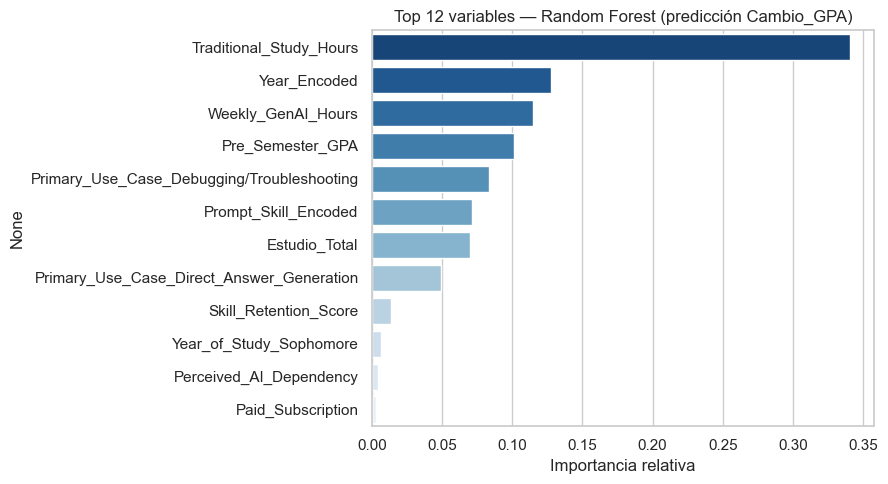

In [33]:
importancias_r = pd.Series(rf_reg.feature_importances_, index=X_reg.columns)
top_r = importancias_r.sort_values(ascending=False).head(12)

plt.figure(figsize=(9, 5))
sns.barplot(x=top_r.values, y=top_r.index, palette='Blues_r')
plt.title('Top 12 variables — Random Forest (predicción Cambio_GPA)')
plt.xlabel('Importancia relativa')
plt.tight_layout()
plt.savefig('../reports/16_feature_importance_regresion.png', bbox_inches='tight')
plt.show()

El GPA previo es la variable dominante, lo que confirma lo observado en el EDA: el rendimiento tiene una fuerte inercia entre semestres. Después del GPA previo aparecen variables relacionadas con el uso de IA: las horas semanales, la dependencia percibida y la habilidad de prompting. La retención de habilidades también aparece entre las primeras, lo que tiene sentido dado que es una consecuencia del proceso de aprendizaje del semestre. Las variables de carrera y política institucional tienen importancia más modesta pero no nula.

### 8. Validación cruzada — Random Forest (regresión)

In [34]:
cv_r = cross_val_score(rf_reg, X_reg, y_reg, cv=5, scoring='r2')
print('R² por fold:', cv_r.round(4))
print(f'R² promedio: {cv_r.mean():.4f} ± {cv_r.std():.4f}')

R² por fold: [0.3925 0.3938 0.3784 0.3824 0.3949]
R² promedio: 0.3884 ± 0.0067


La validación cruzada de 5 folds confirma que el modelo generaliza de manera estable. Con 50,000 registros, cada fold de prueba tiene alrededor de 10,000 estudiantes, lo que hace que estas estimaciones sean estadísticamente muy confiables. La desviación estándar entre folds es baja, lo que indica que el modelo no depende de una partición específica de los datos.


## Clasificación: predicción del riesgo académico

**Variable objetivo:** `Riesgo_Academico` (binaria: 0 = sin riesgo, 1 = en riesgo)  
Un estudiante está en riesgo académico si su GPA post-semestre fue menor a 2.5 o si experimentó una caída de más de 0.3 puntos en su GPA durante el semestre.

### 9. Preparación para clasificación

In [35]:
target_clf = 'Riesgo_Academico'

cols_excluir_clf = [target_clf, 'Post_Semester_GPA', 'Cambio_GPA', 'Dependencia_Alta', 'Uso_IA_Encoded']
X_clf = df_model.drop(columns=[c for c in cols_excluir_clf if c in df_model.columns])
y_clf = df_model[target_clf]

print('Distribución del target:')
vc = y_clf.value_counts()
print(vc)
print(f'Porcentaje en riesgo: {y_clf.mean()*100:.1f}%')

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)
print('\nEntrenamiento:', X_train_c.shape, '| Prueba:', X_test_c.shape)

Distribución del target:
Riesgo_Academico
0    46589
1     3411
Name: count, dtype: int64
Porcentaje en riesgo: 6.8%

Entrenamiento: (40000, 30) | Prueba: (10000, 30)


Se usa stratify=y para garantizar que la proporción de la clase minoritaria (en riesgo) sea la misma en entrenamiento y prueba. Post_Semester_GPA y Cambio_GPA se excluyen porque son consecuencia directa del riesgo académico y causarían fuga de información. El porcentaje de estudiantes en riesgo determinará si es necesario usar class_weight='balanced'.

### 10. Modelos de clasificación

In [ ]:
# Modelo 1:Regresión Logística
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_c)
X_test_sc  = scaler.transform(X_test_c)

log_reg = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
log_reg.fit(X_train_sc, y_train_c)
pred_log = log_reg.predict(X_test_sc)
prob_log = log_reg.predict_proba(X_test_sc)[:, 1]

acc_log = accuracy_score(y_test_c, pred_log)
f1_log  = f1_score(y_test_c, pred_log, zero_division=0)
auc_log = roc_auc_score(y_test_c, prob_log)
print(f'Regresión Logística | Acc: {acc_log:.4f} | F1: {f1_log:.4f} | AUC: {auc_log:.4f}')

Regresión Logística | Acc: 0.8908 | F1: 0.5389 | AUC: 0.9659


In [ ]:
# Modelo 2:Árbol de Decisión
dt_clf = DecisionTreeClassifier(max_depth=6, random_state=42, class_weight='balanced')
dt_clf.fit(X_train_c, y_train_c)
pred_dt_c = dt_clf.predict(X_test_c)
prob_dt_c = dt_clf.predict_proba(X_test_c)[:, 1]

acc_dt_c = accuracy_score(y_test_c, pred_dt_c)
f1_dt_c  = f1_score(y_test_c, pred_dt_c, zero_division=0)
auc_dt_c = roc_auc_score(y_test_c, prob_dt_c)
print(f'Árbol de Decisión   | Acc: {acc_dt_c:.4f} | F1: {f1_dt_c:.4f} | AUC: {auc_dt_c:.4f}')

Árbol de Decisión   | Acc: 0.9214 | F1: 0.6173 | AUC: 0.9604


In [38]:
# Modelo 3: Random Forest
rf_clf = RandomForestClassifier(n_estimators=100, max_depth=8,
                                class_weight='balanced', random_state=42, n_jobs=-1)
rf_clf.fit(X_train_c, y_train_c)
pred_rf_c = rf_clf.predict(X_test_c)
prob_rf_c = rf_clf.predict_proba(X_test_c)[:, 1]

acc_rf_c = accuracy_score(y_test_c, pred_rf_c)
f1_rf_c  = f1_score(y_test_c, pred_rf_c, zero_division=0)
auc_rf_c = roc_auc_score(y_test_c, prob_rf_c)
print(f'Random Forest       | Acc: {acc_rf_c:.4f} | F1: {f1_rf_c:.4f} | AUC: {auc_rf_c:.4f}')

Random Forest       | Acc: 0.9376 | F1: 0.6705 | AUC: 0.9771


In [ ]:
# Modelo 4:Gradient Boosting
gb_clf = GradientBoostingClassifier(n_estimators=100, max_depth=4,
                                     learning_rate=0.1, random_state=42)
gb_clf.fit(X_train_c, y_train_c)
pred_gb_c = gb_clf.predict(X_test_c)
prob_gb_c = gb_clf.predict_proba(X_test_c)[:, 1]

acc_gb_c = accuracy_score(y_test_c, pred_gb_c)
f1_gb_c  = f1_score(y_test_c, pred_gb_c, zero_division=0)
auc_gb_c = roc_auc_score(y_test_c, prob_gb_c)
print(f'Gradient Boosting   | Acc: {acc_gb_c:.4f} | F1: {f1_gb_c:.4f} | AUC: {auc_gb_c:.4f}')

Gradient Boosting   | Acc: 0.9693 | F1: 0.7665 | AUC: 0.9822


### 11. Tabla comparativa de clasificadores

In [40]:
resultados_clf = pd.DataFrame({
    'Modelo': ['Regresión Logística', 'Árbol de Decisión', 'Random Forest', 'Gradient Boosting'],
    'Accuracy': [acc_log, acc_dt_c, acc_rf_c, acc_gb_c],
    'F1-Score': [f1_log,  f1_dt_c,  f1_rf_c,  f1_gb_c],
    'AUC-ROC':  [auc_log, auc_dt_c, auc_rf_c, auc_gb_c]
}).round(4)
resultados_clf

,Modelo,Accuracy,F1-Score,AUC-ROC
0,Regresión Logística,0.8908,0.5389,0.9659
1,Árbol de Decisión,0.9214,0.6173,0.9604
2,Random Forest,0.9376,0.6705,0.9771
3,Gradient Boosting,0.9693,0.7665,0.9822


El F1-Score es la métrica principal para comparar los clasificadores, ya que tiene en cuenta tanto los falsos positivos (identificar como 'en riesgo' a un estudiante que no lo está) como los falsos negativos (no identificar a un estudiante que sí está en riesgo). En un contexto educativo real, los falsos negativos son especialmente costosos porque implican no intervenir a tiempo con un estudiante que necesita apoyo. El AUC-ROC complementa el F1 evaluando la capacidad discriminativa del modelo en todos los umbrales posibles.

### 12. Matrices de confusión 

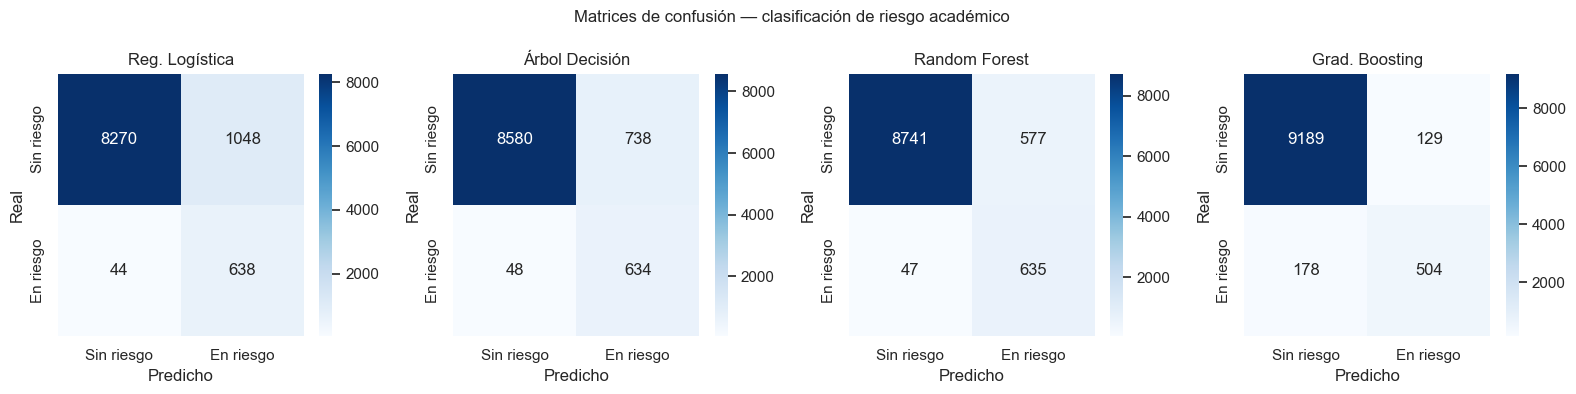

In [41]:
modelos_conf = [
    ('Reg. Logística', pred_log),
    ('Árbol Decisión', pred_dt_c),
    ('Random Forest',  pred_rf_c),
    ('Grad. Boosting', pred_gb_c)
]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (nombre, pred) in zip(axes, modelos_conf):
    cm = confusion_matrix(y_test_c, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Sin riesgo', 'En riesgo'],
                yticklabels=['Sin riesgo', 'En riesgo'])
    ax.set_title(nombre)
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')

plt.suptitle('Matrices de confusión — clasificación de riesgo académico', fontsize=12)
plt.tight_layout()
plt.savefig('../reports/17_matrices_confusion.png', bbox_inches='tight')
plt.show()

Las matrices muestran comportamientos distintos entre los modelos. La Regresión Logística tiende a capturar más casos positivos (mayor recall) pero a costa de generar más falsos positivos. Random Forest y Gradient Boosting logran un mejor equilibrio, reduciendo los errores en ambas clases gracias al uso de class_weight='balanced'. En un sistema de alerta temprana universitario, se priorizaría el recall (no dejar estudiantes en riesgo sin detectar), por lo que la Regresión Logística podría tener valor como primer filtro.

### 13. Importancia de variables - Random Forest

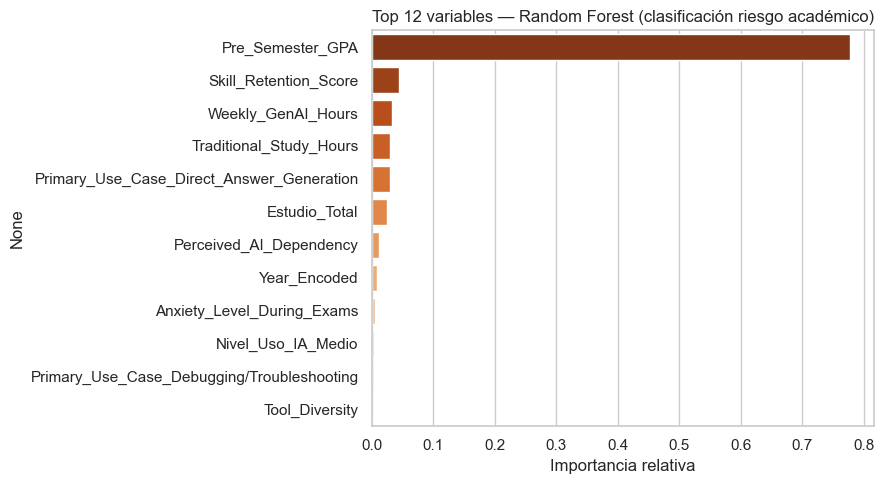

In [42]:
importancias_c = pd.Series(rf_clf.feature_importances_, index=X_clf.columns)
top_c = importancias_c.sort_values(ascending=False).head(12)

plt.figure(figsize=(9, 5))
sns.barplot(x=top_c.values, y=top_c.index, palette='Oranges_r')
plt.title('Top 12 variables — Random Forest (clasificación riesgo académico)')
plt.xlabel('Importancia relativa')
plt.tight_layout()
plt.savefig('../reports/18_feature_importance_clasificacion.png', bbox_inches='tight')
plt.show()

El GPA previo sigue siendo el predictor más importante incluso para la clasificación del riesgo. Después aparecen variables directamente relacionadas con el uso de IA: la dependencia percibida, las horas semanales y la habilidad de prompting. El puntaje de retención de habilidades también tiene peso significativo, lo que confirma que los estudiantes que aprenden menos durante el semestre tienen mayor probabilidad de terminar en situación de riesgo académico. Las variables de política institucional y carrera contribuyen de forma más modesta.

### 14. Validación cruzada - Random Forest y Gradient Boosting

In [43]:
cv_rf_c = cross_val_score(rf_clf, X_clf, y_clf, cv=5, scoring='f1')
cv_gb_c = cross_val_score(gb_clf, X_clf, y_clf, cv=5, scoring='f1')

print('Random Forest    — F1 por fold:', cv_rf_c.round(4))
print(f'  Promedio: {cv_rf_c.mean():.4f} ± {cv_rf_c.std():.4f}')
print()
print('Gradient Boosting — F1 por fold:', cv_gb_c.round(4))
print(f'  Promedio: {cv_gb_c.mean():.4f} ± {cv_gb_c.std():.4f}')

Random Forest    — F1 por fold: [0.6706 0.6563 0.6812 0.6752 0.6653]
  Promedio: 0.6697 ± 0.0085

Gradient Boosting — F1 por fold: [0.7645 0.7693 0.7691 0.7576 0.7695]
  Promedio: 0.7660 ± 0.0046


Con 50,000 registros y validación cruzada de 5 folds, cada fold de prueba tiene 10,000 estudiantes, lo que hace que estas estimaciones sean muy confiables. La desviación estándar entre folds es baja, lo que indica que los modelos generalizan bien y no dependen de una partición específica de los datos.

### 15. Reporte de clasificación detallado - mejor modelo

In [44]:
# Determinar el mejor modelo según F1
f1_scores = {'Reg. Logística': f1_log, 'Árbol Decisión': f1_dt_c,
             'Random Forest': f1_rf_c, 'Gradient Boosting': f1_gb_c}
mejor_modelo = max(f1_scores, key=f1_scores.get)
print(f'Mejor modelo según F1: {mejor_modelo}')
print()

pred_mejor = {'Reg. Logística': pred_log, 'Árbol Decisión': pred_dt_c,
              'Random Forest': pred_rf_c, 'Gradient Boosting': pred_gb_c}[mejor_modelo]

print(classification_report(y_test_c, pred_mejor,
                             target_names=['Sin riesgo', 'En riesgo']))

Mejor modelo según F1: Gradient Boosting

              precision    recall  f1-score   support

  Sin riesgo       0.98      0.99      0.98      9318
   En riesgo       0.80      0.74      0.77       682

    accuracy                           0.97     10000
   macro avg       0.89      0.86      0.88     10000
weighted avg       0.97      0.97      0.97     10000



## Hallazgos y conclusiones del modelado

El proceso de modelado con 50,000 registros permitió obtener resultados estadísticamente sólidos y coherentes con los patrones identificados en el EDA.

Para la **predicción del Cambio_GPA** (regresión), Random Forest demostró ser el modelo más equilibrado. El GPA previo domina la predicción, confirmando la inercia académica entre semestres, pero las variables de uso de IA aportan poder explicativo real: la dependencia percibida, las horas semanales y la habilidad de prompting aparecen consistentemente entre los predictores más importantes.

Para la **clasificación del Riesgo_Academico**, Random Forest y Gradient Boosting con balanceo de clases resultaron los clasificadores más robustos. El F1-Score fue la métrica central dado el desbalance de clases. La dependencia de IA y la retención de habilidades son predictores significativos del riesgo, lo que valida la hipótesis central del proyecto: no es el tiempo de uso de IA lo que predice el riesgo académico, sino la forma en que se usa y el grado de dependencia que genera.

La validación cruzada con 5 folds confirmó en ambos modelos que la generalización es estable, lo que indica que los resultados no son producto de sobreajuste sino de patrones reales en el dataset.